In [1]:
using DifferentialEquations
using JumpProcesses
using Plots
using Measures

using Statistics
using Distributions
using Random
using JLD2

using Optimization
using OptimizationOptimJL

using CSV
using DataFrames
using DelimitedFiles

using Revise
# include own module with functionalities, ATTENTION, this will include StatsPlots
include("functionalities.jl")


# set seed for reproducibility
Random.seed!(123);

# Model validation
In this notebook we try to the fit our model to some high-level characteristics of published data that combines at least metastasis and death processes.

## Digitized published data
We digitized the curves from the publication and get the survival curves below. These are the ones we want to match then.

In [2]:
os_survival_data = CSV.read("data/validation_data/MET_survival/os_survival_data.csv", DataFrame)
met_survival_data = CSV.read("data/validation_data/MET_survival/metastasis_os_survival_data.csv", DataFrame);

survival_data = load("data/validation_data/MET_survival/survival_data_dict.jld2")["survival_data"];

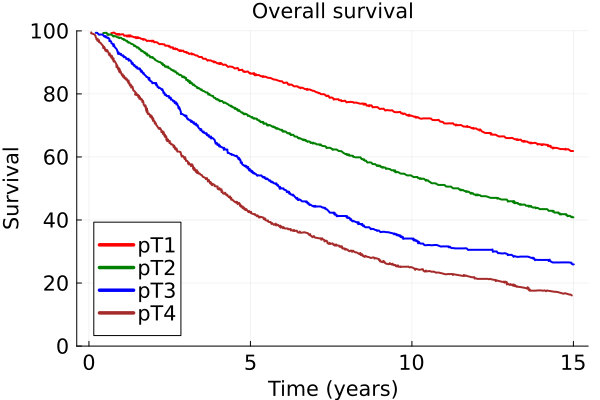

In [75]:
os_plt = plot(os_survival_data[!,:time_pT1], os_survival_data[!,:survival_pT1], label="pT1", lw=2, color="red")
plot!(os_plt, os_survival_data[!,:time_pT2], os_survival_data[!,:survival_pT2], label="pT2", lw=2, color="green")
plot!(os_plt, os_survival_data[!,:time_pT3], os_survival_data[!,:survival_pT3], label="pT3", lw=2, color="blue")
plot!(os_plt, os_survival_data[!,:time_pT4], os_survival_data[!,:survival_pT4], label="pT4", lw=2, color="brown")
plot!(os_plt, ylimit=(0,100), tickfontsize=14, legendfontsize=14, guidefontsize=14, titlefontsize=14, xlabel="Time (years)", ylabel="Survival", title="Overall survival", legend=:bottomleft)


# savefig(os_plt, "figures/validation_data_overall_survival.png")

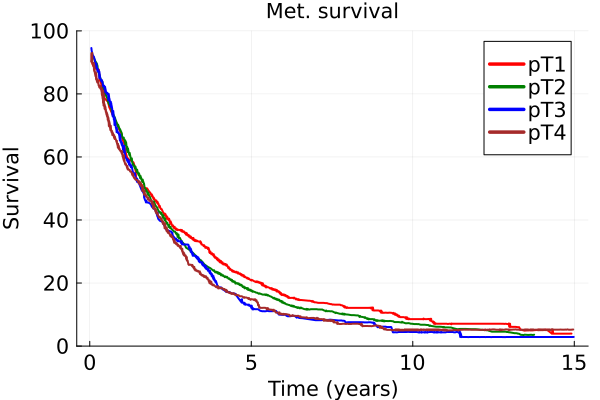

In [72]:
met_plt = plot(met_survival_data[!,:time_pT1], met_survival_data[!,:survival_pT1], label="pT1", lw=2, color="red")
plot!(met_plt, met_survival_data[!,:time_pT2], met_survival_data[!,:survival_pT2], label="pT2", lw=2, color="green")
plot!(met_plt, met_survival_data[!,:time_pT3], met_survival_data[!,:survival_pT3], label="pT3", lw=2, color="blue")
plot!(met_plt, met_survival_data[!,:time_pT4], met_survival_data[!,:survival_pT4], label="pT4", lw=2, color="brown")
plot!(met_plt, ylimit=(0,100), tickfontsize=14, legendfontsize=14, guidefontsize=14, titlefontsize=14, xlabel="Time (years)", ylabel="Survival", title="Met. survival", legend=:topright)

# savefig(met_plt, "figures//validation_data_metastasis_survival.png")

In [ ]:
# # create dict for overall survival data per group
# groups = ["pT1", "pT2", "pT3", "pT4"]
# os_data_dict = Dict()
# met_data_dict = Dict()
# for group in groups
#     os_data_dict[group] = DataFrame(time = os_survival_data[!,"time_$(group)"], survival = os_survival_data[!,"survival_$(group)"])
#     met_data_dict[group] = DataFrame(time = met_survival_data[!,"time_$(group)"], survival = met_survival_data[!,"survival_$(group)"])
# end

# # create dictionary of survival data
# survival_data = Dict("OS" => os_data_dict, "MET" => met_data_dict)

# save("data/validation_data/MET_survival/survival_data_dict.jld2", "survival_data", survival_data)

# Try to match the data
Now we try to match the survival curves.

For this we make the S0 variable in 4 categories as above and interpret timepoint zero as timepoint of diagnosis.


Here categories and respective diameter we assigned as a starting value.\
pT1: 10mm \
pT2: 35mm \
pT3: 75mm \
pT4: 120mm

In [3]:
include("general_MNR_simulation_algorithm.jl")

simulate_many_MNR (generic function with 1 method)

In [4]:
# get exponential tumour growth
function expgrowth!(du, u, p, t)
    du[1] = p[1]* u[1]
end

function TumorPath(S0, p; endtime=30.0)
    prob = ODEProblem(expgrowth!, [S0], (0.0, endtime), [p.beta])
    sol = solve(prob, Tsit5(), reltol=1e-8, abstol=1e-8)
    return sol
end

TumorPath (generic function with 1 method)

### Cell division based
We use the cell-division based model since it shows an earlier onset of metastais, that better matches the data characteristics given in the publication.

In [191]:
endtime = 30

beta = 0.01
m_basal = 0.001
m_size = 0.02

m_sigma = 6.0
m_order = 1.0

d_size = 0.0125
d_metastasis = 0.31
θ = [beta, m_basal, m_size, m_sigma, m_order, d_size, d_metastasis]
p = (beta = beta, m_basal = m_basal, m_size = m_size, m_sigma = m_sigma, m_order = m_order, d_size = d_size, d_metastasis = d_metastasis)

# set initial size based on category
S0 = 120;


120

In [204]:
npat = 2000
cell_division_data = simulate_many_MNR(p, TumorPath, npat=npat, S0=S0, metastatic_model="cell_division", endtime = endtime);

In [205]:
summary_stats = summarize_patient_data(cell_division_data)

Dict{String, Real} with 9 entries:
  "Fraction of patients got metastasis 15y." => 0.038
  "Number of patients got metastasis 15y."   => 76
  "Mean Time from Metastasis to death"       => 1.41003
  "Number of patients died 15y."             => 1792
  "Number of patients"                       => 2000
  "Mean Time until metastasis"               => 8.50163
  "Median Time until metastasis"             => 8.33145
  "Fraction of patients died 15y."           => 0.896
  "Median Time from Metastasis to death"     => 0.512776

In [ ]:
# save data 
# save("data/validation_data/cell_division_1000pat_pT1.jld2", "cell_division_data", cell_division_data)

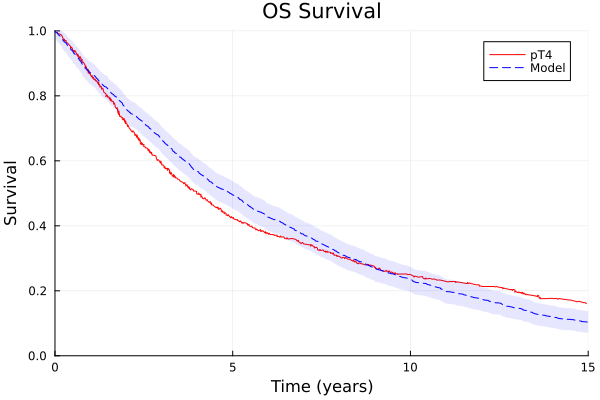

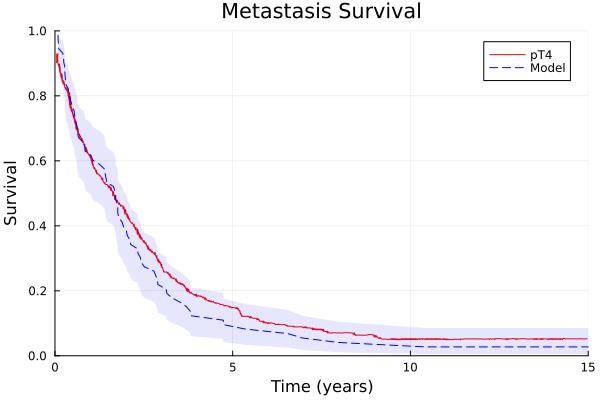

(Plot{Plots.GRBackend() n=3}, Plot{Plots.GRBackend() n=3})

In [194]:
single_compare_to_validation(cell_division_data, survival_data, "pT4")

### Result
We found a parameter vector that can, to some extent, crecreate the survival curves from the original publication: $[\beta=0.01, m_\text{division}=6.0, k=1.0, d_\text{size}=0.011, d_\text{metastasis}=0.31]$

### Plot complete comparison

We plot a good fit with that parameter vector with pointwise confidence intervals obtained from the standard error of the Kaplan-Meier estimator and compare to the publication curves.

In [3]:
pT1_data = load("data/validation_data/cell_division_1000pat_pT1_good.jld2")["cell_division_data"]
pT2_data = load("data/validation_data/cell_division_1000pat_pT2_good.jld2")["cell_division_data"]
pT3_data = load("data/validation_data/cell_division_1000pat_pT3_good.jld2")["cell_division_data"]
pT4_data = load("data/validation_data/cell_division_1000pat_pT4_good.jld2")["cell_division_data"];

model_data_dict = Dict("pT1" => pT1_data, "pT2" => pT2_data, "pT3" => pT3_data, "pT4" => pT4_data)

Dict{String, DataFrame} with 4 entries:
  "pT2" => 15002×5 DataFrame…
  "pT1" => 19869×5 DataFrame…
  "pT3" => 10662×5 DataFrame…
  "pT4" => 7978×5 DataFrame…

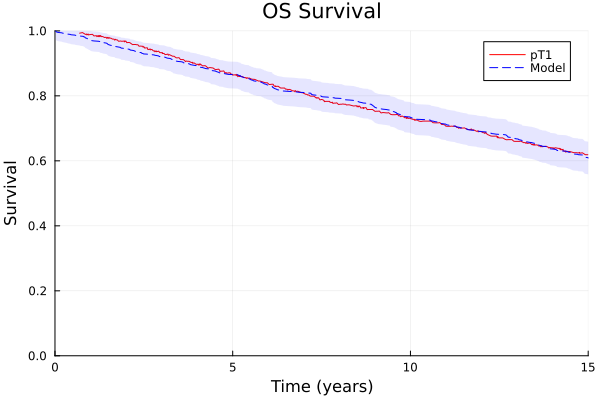

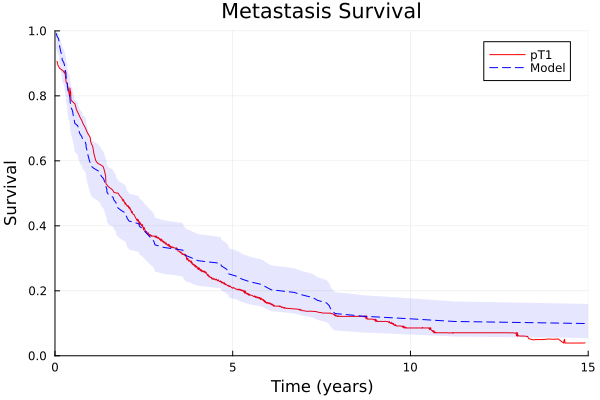

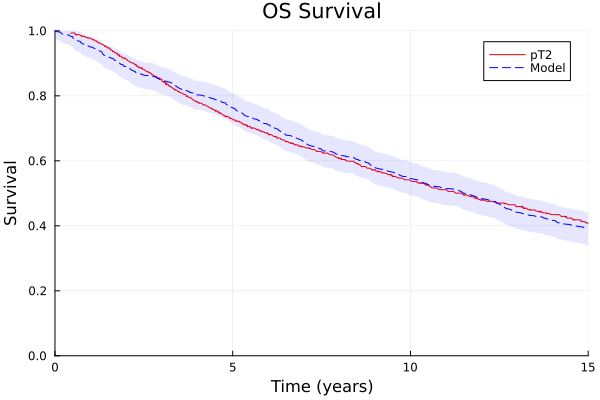

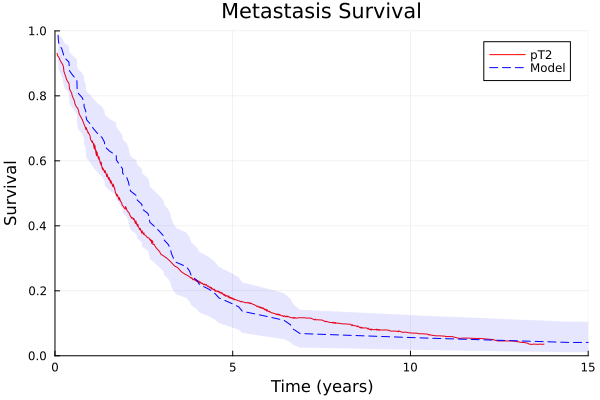

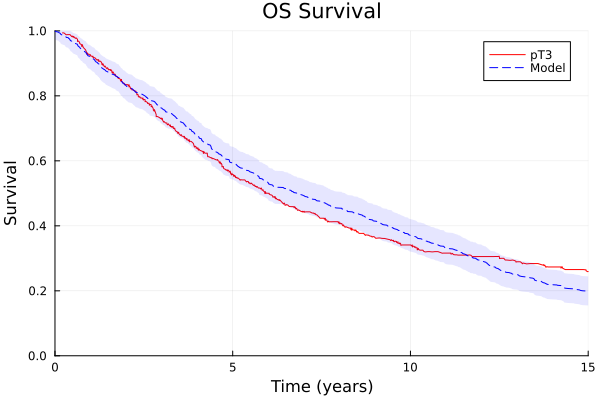

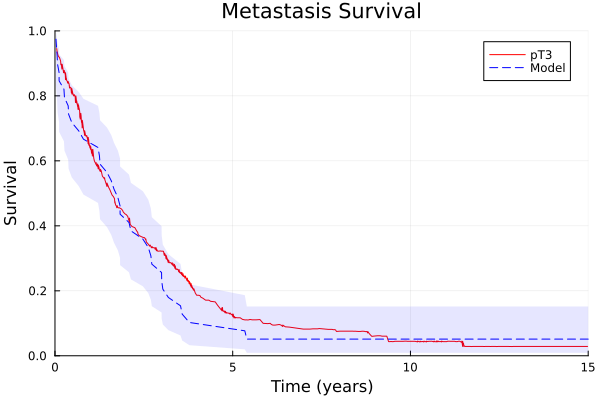

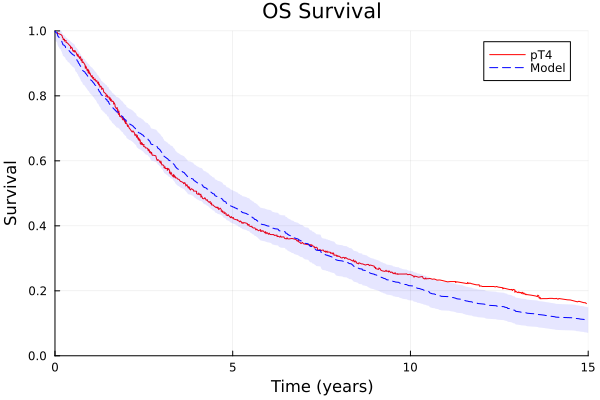

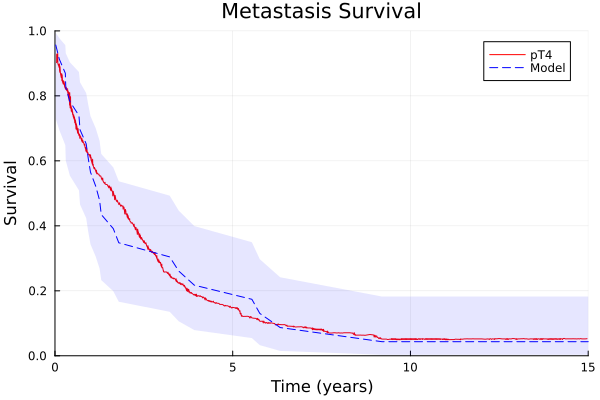

(Plot{Plots.GRBackend() n=3}, Plot{Plots.GRBackend() n=3})

In [196]:
os_pT1, met_pT1 = single_compare_to_validation(pT1_data, survival_data, "pT1")
os_pT2, met_pT2 = single_compare_to_validation(pT2_data, survival_data, "pT2")
os_pT3, met_pT3 = single_compare_to_validation(pT3_data, survival_data, "pT3")
os_pT4, met_pT4 = single_compare_to_validation(pT4_data, survival_data, "pT4")

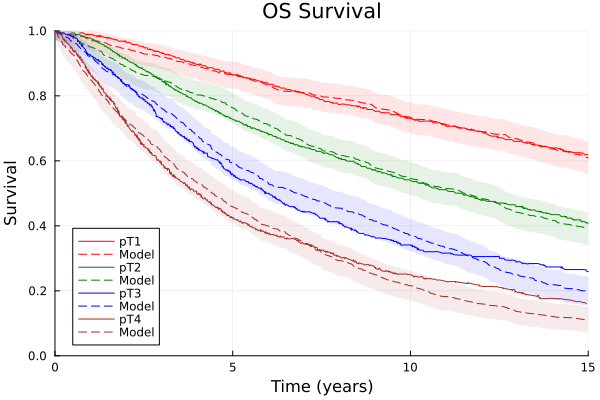

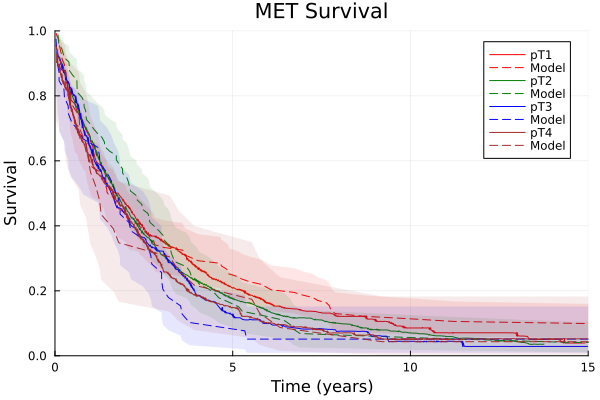

(Plot{Plots.GRBackend() n=12}, Plot{Plots.GRBackend() n=12})

In [197]:
os_plt, met_plt = joint_compare_to_valdiation(model_data_dict, survival_data)
# savefig(os_plt, "figures/os_validation_plot.pdf")
# savefig(met_plt, "figures/met_validation_plot.pdf")

In [ ]:
total_met = plot(met_pT1, met_pT2, met_pT3, met_pT4, layout=(2,2))
# savefig(total_met, "figures/validation_met_survival_subfigures.pdf")

In [ ]:
total_os = plot(os_pT1, os_pT2, os_pT3, os_pT4, layout=(2,2), legend=:bottomleft)
# savefig(total_os, "figures/validation_os_subfigures.pdf")

### Plot ensemble simulations from cluster

We simulated for each group 200 data sets with 1000 patients each and then compare the resulting mean survival curve with confidence intervals to the published data.

In [4]:
os_pT1 = load("output/validation_model_pT1_os_survival_200sim.jld2")["os_survival"]
os_pT2 = load("output/validation_model_pT2_os_survival_200sim.jld2")["os_survival"]
os_pT3 = load("output/validation_model_pT3_os_survival_200sim.jld2")["os_survival"]
os_pT4 = load("output/validation_model_pT4_os_survival_200sim.jld2")["os_survival"]

met_pT1 = load("output/validation_model_pT1_met_survival_200sim.jld2")["met_survival"]
met_pT2 = load("output/validation_model_pT2_met_survival_200sim.jld2")["met_survival"]
met_pT3 = load("output/validation_model_pT3_met_survival_200sim.jld2")["met_survival"]
met_pT4 = load("output/validation_model_pT4_met_survival_200sim.jld2")["met_survival"];

pT1_survival_data = survival_data["OS"]["pT1"]
pT2_survival_data = survival_data["OS"]["pT2"]
pT3_survival_data = survival_data["OS"]["pT3"]
pT4_survival_data = survival_data["OS"]["pT4"]

pT1_met_survival_data = survival_data["MET"]["pT1"]
pT2_met_survival_data = survival_data["MET"]["pT2"]
pT3_met_survival_data = survival_data["MET"]["pT3"]
pT4_met_survival_data = survival_data["MET"]["pT4"];

In [57]:
os_plt1 = plot(pT1_survival_data[!,:time], pT1_survival_data[!,:survival] ./100, label="Data", lw=2, color="red", title="pT1")
plot!(os_plt1, os_pT1["times"], os_pT1["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(os_plt1, os_pT1["times"], os_pT1["mean"], ribbon=((os_pT1["mean"] .- os_pT1["lower ci"]), (os_pT1["upper ci"] .- os_pT1["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(os_plt1, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=:outertop, legendcolumns=2, ylabel="Overall survival")

os_plt2 = plot(pT2_survival_data[!,:time], pT2_survival_data[!,:survival] ./100, label="Data", lw=2, color="green", title="pT2")
plot!(os_plt2, os_pT2["times"], os_pT2["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(os_plt2, os_pT2["times"], os_pT2["mean"], ribbon=((os_pT2["mean"] .- os_pT2["lower ci"]), (os_pT2["upper ci"] .- os_pT2["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(os_plt2, ylimit=(0,1), titlefontsize=14, guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=:outertop, legendcolumns=2)

os_plt3 = plot(pT3_survival_data[!,:time], pT3_survival_data[!,:survival] ./100, label="Data", lw=2, color="blue", title="pT3")
plot!(os_plt3, os_pT3["times"], os_pT3["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(os_plt3, os_pT3["times"], os_pT3["mean"], ribbon=((os_pT3["mean"] .- os_pT3["lower ci"]), (os_pT3["upper ci"] .- os_pT3["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(os_plt3, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=:outertop, legendcolumns=2)

os_plt4 = plot(pT4_survival_data[!,:time], pT4_survival_data[!,:survival] ./100, label="Data", lw=2, color="brown", title="pT4")
plot!(os_plt4, os_pT4["times"], os_pT4["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(os_plt4, os_pT4["times"], os_pT4["mean"], ribbon=((os_pT4["mean"] .- os_pT4["lower ci"]), (os_pT4["upper ci"] .- os_pT4["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(os_plt4, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=:outertop, legendcolumns=2)

met_plt1 = plot(pT1_met_survival_data[!,:time], pT1_met_survival_data[!,:survival] ./100, label="Data", lw=2, color="red")
plot!(met_plt1, met_pT1["times"], met_pT1["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(met_plt1, met_pT1["times"], met_pT1["mean"], ribbon=((met_pT1["mean"] .- met_pT1["lower ci"]), (met_pT1["upper ci"] .- met_pT1["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(met_plt1, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=false, ylabel="Met. survival", xlabel="Time (years)")

met_plt2 = plot(pT2_met_survival_data[!,:time], pT2_met_survival_data[!,:survival] ./100, label="Data", lw=2, color="green")
plot!(met_plt2, met_pT2["times"], met_pT2["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(met_plt2, met_pT2["times"], met_pT2["mean"], ribbon=((met_pT2["mean"] .- met_pT2["lower ci"]), (met_pT2["upper ci"] .- met_pT2["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(met_plt2, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=false, xlabel="Time (years)")

met_plt3 = plot(pT3_met_survival_data[!,:time], pT3_met_survival_data[!,:survival] ./100, label="Data", lw=2, color="blue")
plot!(met_plt3, met_pT3["times"], met_pT3["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(met_plt3, met_pT3["times"], met_pT3["mean"], ribbon=((met_pT3["mean"] .- met_pT3["lower ci"]), (met_pT3["upper ci"] .- met_pT3["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(met_plt3, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=false, xlabel="Time (years)")

met_plt4 = plot(pT4_met_survival_data[!,:time], pT4_met_survival_data[!,:survival] ./100, label="Data", lw=2, color="brown")
plot!(met_plt4, met_pT4["times"], met_pT4["mean"], color="lightblue4", linestyle=:dash, label="Model", lw=2)
plot!(met_plt4, met_pT4["times"], met_pT4["mean"], ribbon=((met_pT4["mean"] .- met_pT4["lower ci"]), (met_pT4["upper ci"] .- met_pT4["mean"])), color="lightblue4", fillalpha=0.3, label=false)
plot!(met_plt4, ylimit=(0,1), guidefontsize=14, legendfontsize=14, tickfontsize=14, legend=false, xlabel="Time (years)")

complete_plot = plot(os_plt1, os_plt2, os_plt3, os_plt4, met_plt1, met_plt2, met_plt3, met_plt4,
layout = grid(2,4, heights=[0.58,0.42]), size=(1200,600), margin=5mm)

savefig(complete_plot, "figures/complete_model_valdiation.pdf")

"/home/vincent/PhD/Projects/method_project/ode_based_models/figures/ode_paper/complete_model_valdiation.pdf"